In [1]:
from dolfinx import mesh, fem
from dolfinx.io import XDMFFile
from mpi4py import MPI
import numpy as np
import ufl
from petsc4py import PETSc
import basix
import os
import jax
import jax.numpy as jnp
from jax import jacfwd
from functools import partial
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
jax.config.update("jax_enable_x64", True)

In [2]:
from LargeStrains.ElasticModulus import compute_elastic_tangent_jax
from LargeStrains.TensorsStr import strain_to_voigt, stress_to_voigt, voigt_to_stress
from LargeStrains.RadialReturn_V0 import radial_return_jax
from LargeStrains.BMatrix import compute_B_matrix
from LargeStrains.Assembler import ConsistentTangentAssembler
from LargeStrains.GradU import compute_grad_u_at_qp
from LargeStrains.Residual import assemble_residual
from LargeStrains.HistoryUpd_SS import update_history_and_tangents
from LargeStrains.NewtonUpd import Newton_Solver_FullTangent
from LargeStrains.generic_test_driver import build_test_setup
from LargeStrains.Newton_Generic import Newton_Solver_Generic
from LargeStrains.GradU import compute_grad_u_at_qp

In [11]:
domain = mesh.create_unit_cube(MPI.COMM_WORLD, nx=1, ny=1, nz=1,
                               cell_type=mesh.CellType.hexahedron)
E, nu, Y0, h = 210000.0, 0.3, 250.0, 100.0
#E, nu, Y0, h = 210000.0, 0.0, 105000.0, 2100.0
#E, nu, Y0, h = 2000.0, 0.0, 1000.0, 200.0
mu = E / (2*(1 + nu))
clambda = E*nu / ((1 + nu)*(1 - 2*nu))
delta  = 10.0 #Saturation parameter for nonlinear isotropic hardening
#Y_inf  = E / 2 + E / 10
Y_inf = 500.0
Y_init = Y0

print(f"\nMaterial: E={E}, nu={nu}, Y0={Y0}, h={h}")

#Function spaces
vector_el = basix.ufl.element(basix.ElementFamily.P, domain.topology.cell_name(), 1, shape=(3,))
V = fem.functionspace(domain, vector_el)


Material: E=210000.0, nu=0.3, Y0=250.0, h=100.0


In [4]:
qdeg = 2
basix_cell = basix.CellType.hexahedron
q_el_scalar = basix.ufl.quadrature_element(cell=basix_cell, degree=qdeg, value_shape=())
q_el_tensor = basix.ufl.quadrature_element(cell=basix_cell, degree=qdeg, value_shape=(3, 3))

Q_scalar = fem.functionspace(domain, q_el_scalar)
Q_tensor = fem.functionspace(domain, q_el_tensor)

u = fem.Function(V, name="Displacement")
u_old = fem.Function(V, name="Previous_Displacement")
sigma_q = fem.Function(Q_tensor, name="Stress")
eps_p_q = fem.Function(Q_scalar, name="Plastic_Strain")
Y_q = fem.Function(Q_scalar, name="Yield_Stress")

q_el_vector6 = basix.ufl.quadrature_element(cell=basix_cell, degree=qdeg, value_shape=(6,))
Q_vector6 = fem.functionspace(domain, q_el_vector6)
alpha_q = fem.Function(Q_vector6, name="Backstress")
alpha_q.x.array[:] = 0.0

u.x.array[:] = 0.0
u_old.x.array[:] = 0.0
sigma_q.x.array[:] = 0.0
eps_p_q.x.array[:] = 0.0
Y_q.x.array[:] = Y0

print(f"DOFs: {V.dofmap.index_map.size_global * V.dofmap.index_map_bs}")

DOFs: 24


In [5]:
num_cells = domain.topology.index_map(domain.topology.dim).size_local
qp_points, qp_weights = basix.make_quadrature(basix.CellType.hexahedron, qdeg)
num_qp = qp_points.shape[0]

scalar_element = basix.create_element(basix.ElementFamily.P, basix.CellType.hexahedron, 1,
                                      basix.LagrangeVariant.equispaced)
tab = scalar_element.tabulate(1, qp_points)
num_nodes = tab[0].shape[1]

#Basis function gradients: basis_grad[qp, node, direction]
basis_grad = np.zeros((num_qp, num_nodes, 3))
basis_grad[:, :, 0] = tab[1, :, :, 0]  # dN/dx
basis_grad[:, :, 1] = tab[2, :, :, 0]  # dN/dy
basis_grad[:, :, 2] = tab[3, :, :, 0]  # dN/dz

print(f"Quadrature: {num_cells} cells x {num_qp} points = {num_cells * num_qp} total QPs")
print(f"Basis functions: {num_nodes} nodes")

Quadrature: 1 cells x 8 points = 8 total QPs
Basis functions: 8 nodes


In [6]:
def get_right_face_dofs(domain, V):
    from dolfinx import mesh as msh
    #Locate boundary facets on x=1
    right_facets = msh.locate_entities_boundary(
        domain, domain.topology.dim - 1,
        lambda x: np.isclose(x[0], 1.0)
    )
    #Locate DOFs on those facets
    right_dofs = fem.locate_dofs_topological(V, domain.topology.dim - 1, right_facets)
    return right_dofs

right_face_dofs = get_right_face_dofs(domain, V)
print(f"Right face DOFs: {right_face_dofs}")

Right face DOFs: [1 3 5 7]


In [7]:
def boundary_x0(x):
    return np.isclose(x[0], 0.0)

bc_dofs = fem.locate_dofs_geometrical(V, boundary_x0)
print(f"Fixed DOFs: {len(bc_dofs)}")

Fixed DOFs: 4


Updated with paper

In [16]:
#For paper's configurations, we have:
E    = 1.0       # paper uses E as unit
nu   = 0.0       # paper uses ν = 0
Y0   = E / 2     # = 0.5
h    = E / 100   # = 0.01  (paper calls this E_p)

  COMPARISON   |   paper_uniaxial   |   linear_isotropic

──────────────────────────────────────────────────────────────────────
  Uniaxial extension (paper §4.3, y,z clamped) | strain = small | linear_isotropic
  control mode: displacement
──────────────────────────────────────────────────────────────────────

Newton  (cumulative load = 0.05):
   iter  0:  |du|=0.000e+00   rel=0.000e+00
   iter  1:  |du|=0.000e+00   rel=0.000e+00
   ✓ converged in 2 iterations
   status: ELASTIC
   max eps_p (cumulative) = 0.000000e+00   max Δeps_p (this step) = 0.000000e+00   max Y = 0.5000

Newton  (cumulative load = 0.1):
   iter  0:  |du|=0.000e+00   rel=0.000e+00
   iter  1:  |du|=0.000e+00   rel=0.000e+00
   ✓ converged in 2 iterations
   status: ELASTIC
   max eps_p (cumulative) = 0.000000e+00   max Δeps_p (this step) = 0.000000e+00   max Y = 0.5000

Newton  (cumulative load = 0.15):
   iter  0:  |du|=0.000e+00   rel=0.000e+00
   iter  1:  |du|=0.000e+00   rel=0.000e+00
   ✓ converged in 2 iter

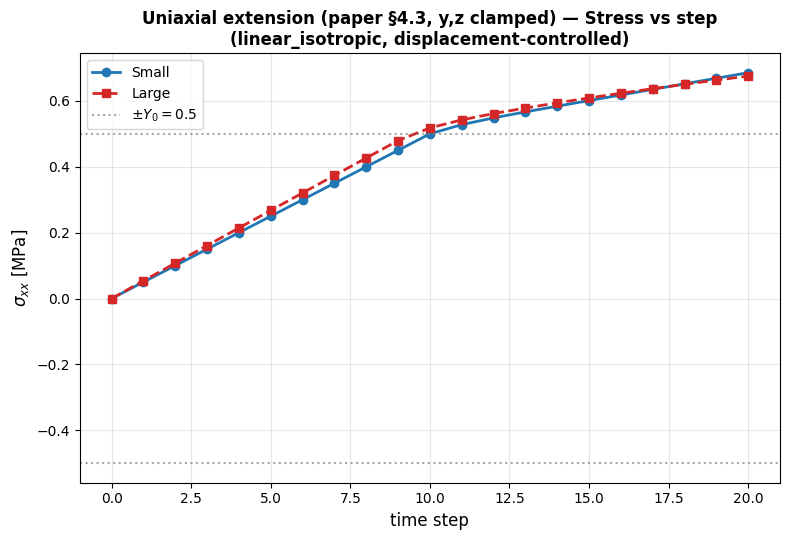

  saved: stress_step_paper_uniaxial_linear_isotropic.png


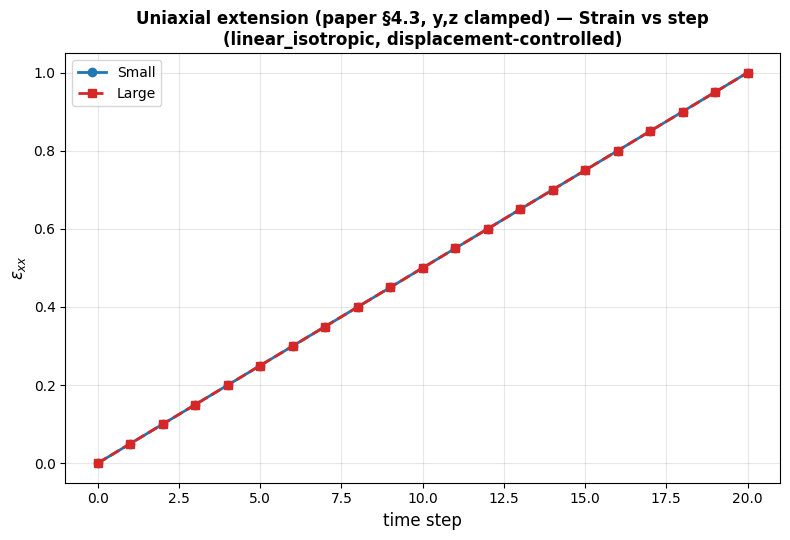

  saved: strain_step_paper_uniaxial_linear_isotropic.png


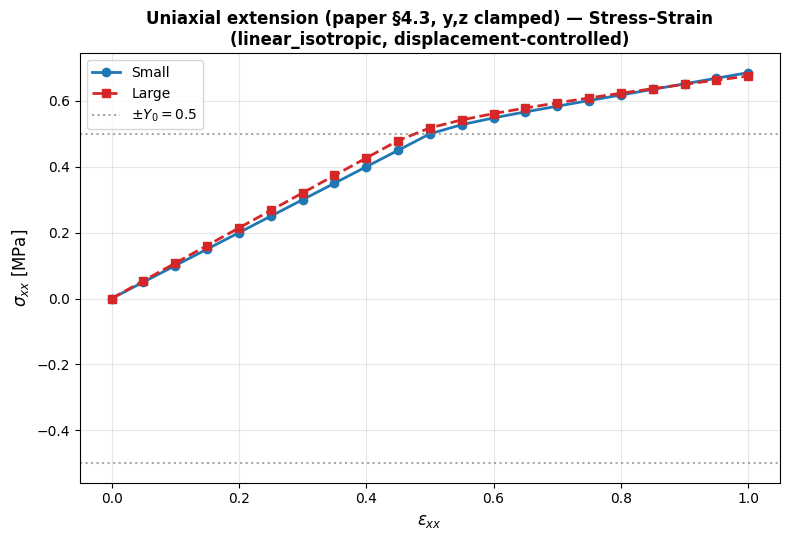

  saved: stress_strain_paper_uniaxial_linear_isotropic.png


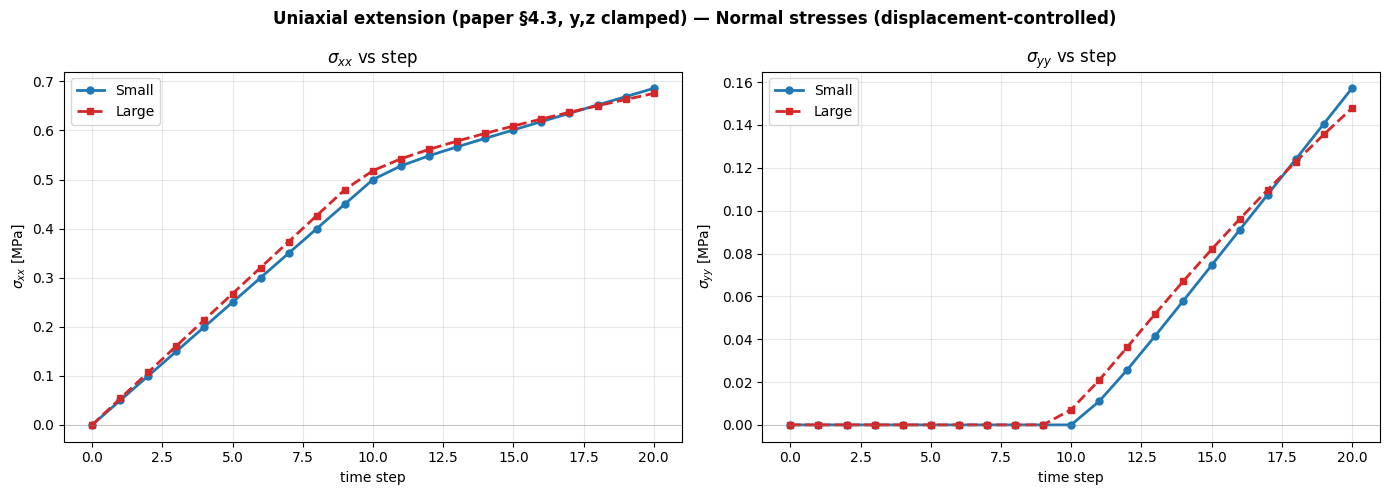

  saved: normal_components_paper_uniaxial_linear_isotropic.png

  Step-by-step difference  (LS − SS)  |  control = displacement
   step     ε_xx (SS)     ε_xx (LS)     σ_xx (SS)     σ_xx (LS)            Δσ
  ------------------------------------------------------------------------------
      0  0.000000e+00  0.000000e+00        0.0000        0.0000        0.0000
      2  1.000000e-01  1.000000e-01        0.1000        0.1074        0.0074
      4  2.000000e-01  2.000000e-01        0.2000        0.2143        0.0143
      6  3.000000e-01  3.000000e-01        0.3000        0.3207        0.0207
      8  4.000000e-01  4.000000e-01        0.4000        0.4267        0.0267
     10  5.000000e-01  5.000000e-01        0.5000        0.5181        0.0181
     12  6.000000e-01  6.000000e-01        0.5485        0.5615        0.0130
     14  7.000000e-01  7.000000e-01        0.5840        0.5941        0.0101
     16  8.000000e-01  8.000000e-01        0.6181        0.6234        0.0053
     18  9.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  COMPARE small vs large1 — stress / strain vs time step
#
#  Auto-detects control mode (traction or displacement) from the test setup
#  and adjusts axis labels / which plots are most informative.
#
#  Test types available:
#    Traction-driven      : 'uniaxial' (3000) | 'compression' (3000) | 'biaxial' | 'shear_traction'(250)
#    Displacement-driven  : 'uniaxial_disp' | 'compression_disp' | 'biaxial_disp' | 'shear'
#    Paper comparison        : 'paper_ext_comp' (use P=1) | 'paper_dilatation' | 'paper_uniaxial'| 'paper_ext_rot'
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from LargeStrains.generic_test_driver import build_test_setup
from LargeStrains.Newton_Generic   import Newton_Solver_Generic
from LargeStrains.GradU            import compute_grad_u_at_qp


# ── CONFIG ─────────────────────────────────────────────────────────────────
TEST       = 'uniaxial'    # see list above
P_MAX      = 400              # for traction tests: stress (MPa)
                                # for *_disp tests: target strain
                                # for 'shear': target γ
NUM_STEPS  = 20
HARDENING  = 'linear_isotropic'
NEWTON_IT  = 50
# ───────────────────────────────────────────────────────────────────────────


def _reset():
    u.x.array[:]       = 0.0
    u_old.x.array[:]   = 0.0
    sigma_q.x.array[:] = 0.0
    eps_p_q.x.array[:] = 0.0
    Y_q.x.array[:]     = Y0
    alpha_q.x.array[:] = 0.0


def _avg_strain():
    eps_sum, n = np.zeros((3, 3)), 0
    for c in range(num_cells):
        for q in range(num_qp):
            grad_u = compute_grad_u_at_qp(u, c, q, basis_grad, V)
            eps_sum += 0.5 * (grad_u + grad_u.T)
            n += 1
    return eps_sum / n


def _run(strain):
    setup = build_test_setup(TEST, V, domain, P_MAX, NUM_STEPS)
    print(f"\n{'─'*70}")
    print(f"  {setup['label']} | strain = {strain} | {HARDENING}")
    print(f"  control mode: {setup['control']}")
    print(f"{'─'*70}")

    _reset()
    assembler = ConsistentTangentAssembler(
        V, num_cells, num_qp, basis_grad, qp_weights, E, nu)

    sxx, syy, szz = [0.0], [0.0], [0.0]
    sxy, sxz, syz = [0.0], [0.0], [0.0]
    exx, eyy, ezz = [0.0], [0.0], [0.0]
    exy, exz, eyz = [0.0], [0.0], [0.0]
    eps_p         = [0.0]

    for n, step in enumerate(setup['load_path']):
        Newton_Solver_Generic(
            V, u, u_old, sigma_q, eps_p_q, Y_q, alpha_q, assembler,
            NEWTON_IT, num_cells, num_qp, basis_grad, qp_weights,
            setup['primary_face_dofs'], setup['bc_per_component'],
            E, nu, Y0, h, Y_init, Y_inf, delta,
            cumulative_traction   = step['cumulative_traction'],
            traction_vec_override = step['traction_vec_override'],
            extra_tractions       = step['extra_tractions'],
            prescribed_values     = step['prescribed_values'],
            strain=strain, hardening=HARDENING,
        )

        sigma_arr = sigma_q.x.array.reshape(num_cells, num_qp, 3, 3)
        sxx.append(np.mean(sigma_arr[:, :, 0, 0]))
        syy.append(np.mean(sigma_arr[:, :, 1, 1]))
        szz.append(np.mean(sigma_arr[:, :, 2, 2]))
        sxy.append(np.mean(sigma_arr[:, :, 0, 1]))
        sxz.append(np.mean(sigma_arr[:, :, 0, 2]))
        syz.append(np.mean(sigma_arr[:, :, 1, 2]))

        eps_avg = _avg_strain()
        exx.append(eps_avg[0, 0]); eyy.append(eps_avg[1, 1]); ezz.append(eps_avg[2, 2])
        exy.append(eps_avg[0, 1]); exz.append(eps_avg[0, 2]); eyz.append(eps_avg[1, 2])

        eps_p.append(np.max(eps_p_q.x.array))

    return dict(
        label=setup['label'], control=setup['control'],
        sxx=np.array(sxx), syy=np.array(syy), szz=np.array(szz),
        sxy=np.array(sxy), sxz=np.array(sxz), syz=np.array(syz),
        exx=np.array(exx), eyy=np.array(eyy), ezz=np.array(ezz),
        exy=np.array(exy), exz=np.array(exz), eyz=np.array(eyz),
        eps_p=np.array(eps_p),
    )


# ── Run both formulations ─────────────────────────────────────────────────
print("="*70)
print(f"  COMPARISON   |   {TEST}   |   {HARDENING}")
print("="*70)
res_ss = _run('small')
res_ls = _run('large1')

steps   = np.arange(NUM_STEPS + 1)
control = res_ss['control']            # 'traction' or 'displacement'

is_shear = TEST in ('shear', 'shear_traction')


# ═══════════════════════════════════════════════════════════════════════════
#  Plot helpers
# ═══════════════════════════════════════════════════════════════════════════
def _save_show(fig, fname):
    fig.tight_layout()
    fig.savefig(fname, dpi=180, bbox_inches='tight')
    plt.show()
    print(f"  saved: {fname}")


def plot_stress_vs_step():
    fig, ax = plt.subplots(figsize=(8, 5.5))
    if is_shear:
        ax.plot(steps, res_ss['sxz'], '-o',  color='tab:blue', lw=2, ms=6, label='Small')
        ax.plot(steps, res_ls['sxz'], '--s', color='tab:red',  lw=2, ms=6, label='Large')
        ax.axhline( Y0/np.sqrt(3), ls=':', color='gray', alpha=0.7,
                    label=fr'$\pm Y_0/\sqrt{{3}} = {Y0/np.sqrt(3):.1f}$')
        ax.axhline(-Y0/np.sqrt(3), ls=':', color='gray', alpha=0.7)
        ax.set_ylabel(r'$\sigma_{xz}$ [MPa]', fontsize=12)
    else:
        ax.plot(steps, res_ss['sxx'], '-o',  color='tab:blue', lw=2, ms=6, label='Small')
        ax.plot(steps, res_ls['sxx'], '--s', color='tab:red',  lw=2, ms=6, label='Large')
        ax.axhline( Y0, ls=':', color='gray', alpha=0.7, label=fr'$\pm Y_0 = {Y0}$')
        ax.axhline(-Y0, ls=':', color='gray', alpha=0.7)
        ax.set_ylabel(r'$\sigma_{xx}$ [MPa]', fontsize=12)

    ax.set_xlabel('time step', fontsize=12)
    ax.set_title(f"{res_ss['label']} — Stress vs step\n"
                 f"({HARDENING}, {control}-controlled)",
                 fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3); ax.legend(fontsize=10)
    _save_show(fig, f'stress_step_{TEST}_{HARDENING}.png')


def plot_strain_vs_step():
    fig, ax = plt.subplots(figsize=(8, 5.5))
    if is_shear:
        gamma_ss = 2.0 * res_ss['exz']
        gamma_ls = 2.0 * res_ls['exz']
        ax.plot(steps, gamma_ss, '-o',  color='tab:blue', lw=2, ms=6, label='Small')
        ax.plot(steps, gamma_ls, '--s', color='tab:red',  lw=2, ms=6, label='Large')
        ax.set_ylabel(r'$\gamma_{xz}$', fontsize=12)
    else:
        ax.plot(steps, res_ss['exx'], '-o',  color='tab:blue', lw=2, ms=6, label='Small')
        ax.plot(steps, res_ls['exx'], '--s', color='tab:red',  lw=2, ms=6, label='Large')
        ax.set_ylabel(r'$\varepsilon_{xx}$', fontsize=12)

    ax.set_xlabel('time step', fontsize=12)
    ax.set_title(f"{res_ss['label']} — Strain vs step\n"
                 f"({HARDENING}, {control}-controlled)",
                 fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3); ax.legend(fontsize=10)
    _save_show(fig, f'strain_step_{TEST}_{HARDENING}.png')


def plot_stress_strain():
    """Classic σ-ε curve. The plot that always shows the bilinear yield knee."""
    fig, ax = plt.subplots(figsize=(8, 5.5))
    if is_shear:
        gamma_ss = 2.0 * res_ss['exz']
        gamma_ls = 2.0 * res_ls['exz']
        ax.plot(gamma_ss, res_ss['sxz'], '-o',  color='tab:blue', lw=2, ms=6, label='Small')
        ax.plot(gamma_ls, res_ls['sxz'], '--s', color='tab:red',  lw=2, ms=6, label='Large')
        ax.axhline( Y0/np.sqrt(3), ls=':', color='gray', alpha=0.7,
                    label=fr'$\pm Y_0/\sqrt{{3}} = {Y0/np.sqrt(3):.1f}$')
        ax.axhline(-Y0/np.sqrt(3), ls=':', color='gray', alpha=0.7)
        ax.set_xlabel(r'$\gamma_{xz}$', fontsize=12)
        ax.set_ylabel(r'$\sigma_{xz}$ [MPa]', fontsize=12)
    else:
        ax.plot(res_ss['exx'], res_ss['sxx'], '-o',  color='tab:blue', lw=2, ms=6, label='Small')
        ax.plot(res_ls['exx'], res_ls['sxx'], '--s', color='tab:red',  lw=2, ms=6, label='Large')
        ax.axhline( Y0, ls=':', color='gray', alpha=0.7, label=fr'$\pm Y_0 = {Y0}$')
        ax.axhline(-Y0, ls=':', color='gray', alpha=0.7)
        ax.set_xlabel(r'$\varepsilon_{xx}$', fontsize=12)
        ax.set_ylabel(r'$\sigma_{xx}$ [MPa]', fontsize=12)

    ax.set_title(f"{res_ss['label']} — Stress–Strain\n"
                 f"({HARDENING}, {control}-controlled)",
                 fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3); ax.legend(fontsize=10)
    _save_show(fig, f'stress_strain_{TEST}_{HARDENING}.png')


def plot_normal_components_vs_step():
    """All 3 normal stresses vs step — useful to see Poynting effect in shear."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, comp_name, tex in [(axes[0], 'sxx', r'$\sigma_{xx}$'),
                                (axes[1], 'syy', r'$\sigma_{yy}$')]:
        ax.plot(steps, res_ss[comp_name], '-o',  color='tab:blue', lw=2, ms=5, label='Small')
        ax.plot(steps, res_ls[comp_name], '--s', color='tab:red',  lw=2, ms=5, label='Large')
        ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
        ax.set_xlabel('time step')
        ax.set_ylabel(f'{tex} [MPa]')
        ax.set_title(f'{tex} vs step')
        ax.grid(alpha=0.3); ax.legend()

    fig.suptitle(f"{res_ss['label']} — Normal stresses ({control}-controlled)",
                 fontsize=12, fontweight='bold')
    _save_show(fig, f'normal_components_{TEST}_{HARDENING}.png')


# ── Generate plots ─────────────────────────────────────────────────────────
print("\n── plotting ──")
plot_stress_vs_step()
plot_strain_vs_step()
plot_stress_strain()
plot_normal_components_vs_step()


# ── Numerical comparison table ────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  Step-by-step difference  (LS − SS)  |  control = {control}")
print(f"{'='*70}")

if is_shear:
    print(f"  {'step':>5} {'γ_xz (SS)':>13} {'γ_xz (LS)':>13} "
          f"{'σ_xz (SS)':>13} {'σ_xz (LS)':>13} {'σ_xx (LS)':>13}")
    print(f"  {'-'*78}")
    for n in range(0, NUM_STEPS + 1, max(1, NUM_STEPS // 10)):
        print(f"  {n:>5d} "
              f"{2*res_ss['exz'][n]:>13.6e} {2*res_ls['exz'][n]:>13.6e} "
              f"{res_ss['sxz'][n]:>13.4f} {res_ls['sxz'][n]:>13.4f} "
              f"{res_ls['sxx'][n]:>13.4f}")
else:
    print(f"  {'step':>5} {'ε_xx (SS)':>13} {'ε_xx (LS)':>13} "
          f"{'σ_xx (SS)':>13} {'σ_xx (LS)':>13} {'Δσ':>13}")
    print(f"  {'-'*78}")
    for n in range(0, NUM_STEPS + 1, max(1, NUM_STEPS // 10)):
        print(f"  {n:>5d} "
              f"{res_ss['exx'][n]:>13.6e} {res_ls['exx'][n]:>13.6e} "
              f"{res_ss['sxx'][n]:>13.4f} {res_ls['sxx'][n]:>13.4f} "
              f"{res_ls['sxx'][n] - res_ss['sxx'][n]:>13.4f}")
print(f"{'='*70}")

In [19]:
# ═══════════════════════════════════════════════════════════════════════════
#  EXPORT PLOT DATA TO EXCEL — paste as a notebook cell
#  Run this AFTER the comparison cell that produces res_ss and res_ls.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# ── CONFIG ─────────────────────────────────────────────────────────────────
OUTPUT_FILE = f"results_{TEST}_{HARDENING}.xlsx"
# ───────────────────────────────────────────────────────────────────────────

steps = np.arange(NUM_STEPS + 1)
wb    = Workbook()

# ── Styles ─────────────────────────────────────────────────────────────────
hdr_font    = Font(bold=True, name='Arial', size=10)
hdr_fill_ss = PatternFill('solid', start_color='DDEEFF')   # light blue  — small strain
hdr_fill_ls = PatternFill('solid', start_color='FFE5E5')   # light red   — large strain
hdr_fill_meta = PatternFill('solid', start_color='E8E8E8') # grey        — step / meta
thin = Side(style='thin', color='999999')
border = Border(left=thin, right=thin, top=thin, bottom=thin)
center = Alignment(horizontal='center', vertical='center')
num_fmt = '0.000000'


def _style_header(cell, fill):
    cell.font      = hdr_font
    cell.fill      = fill
    cell.alignment = center
    cell.border    = border


def _style_data(cell):
    cell.number_format = num_fmt
    cell.alignment     = Alignment(horizontal='right')
    cell.border        = border


# ══════════════════════════════════════════════════════════════════════════
#  Sheet 1 — Stress vs Step  (the main plot you showed)
# ══════════════════════════════════════════════════════════════════════════
ws1 = wb.active
ws1.title = 'Stress vs Step'

is_shear = TEST in ('shear', 'shear_traction')

# Meta info
ws1['A1'] = 'Test'       ; ws1['B1'] = TEST
ws1['A2'] = 'Hardening'  ; ws1['B2'] = HARDENING
ws1['A3'] = 'Num Steps'  ; ws1['B3'] = NUM_STEPS
ws1['A4'] = 'P_MAX'      ; ws1['B4'] = P_MAX
for r in range(1, 5):
    ws1.cell(r, 1).font = Font(bold=True, name='Arial', size=10)

# Column headers  (row 6)
HDR_ROW = 6
if is_shear:
    headers = [
        ('Step',              hdr_fill_meta),
        ('σ_xz SS [MPa]',     hdr_fill_ss),
        ('σ_xz LS [MPa]',     hdr_fill_ls),
        ('Δσ_xz (LS−SS)',     hdr_fill_meta),
        ('γ_xz SS',           hdr_fill_ss),
        ('γ_xz LS',           hdr_fill_ls),
        ('σ_xx SS [MPa]',     hdr_fill_ss),
        ('σ_xx LS [MPa]',     hdr_fill_ls),
        ('eps_p SS',          hdr_fill_ss),
        ('eps_p LS',          hdr_fill_ls),
    ]
    data_cols = [
        steps,
        res_ss['sxz'], res_ls['sxz'],
        res_ls['sxz'] - res_ss['sxz'],
        2*res_ss['exz'], 2*res_ls['exz'],
        res_ss['sxx'], res_ls['sxx'],
        res_ss['eps_p'], res_ls['eps_p'],
    ]
else:
    headers = [
        ('Step',              hdr_fill_meta),
        ('σ_xx SS [MPa]',     hdr_fill_ss),
        ('σ_xx LS [MPa]',     hdr_fill_ls),
        ('Δσ_xx (LS−SS)',     hdr_fill_meta),
        ('σ_yy SS [MPa]',     hdr_fill_ss),
        ('σ_yy LS [MPa]',     hdr_fill_ls),
        ('ε_xx SS',           hdr_fill_ss),
        ('ε_xx LS',           hdr_fill_ls),
        ('ε_yy SS',           hdr_fill_ss),
        ('ε_yy LS',           hdr_fill_ls),
        ('eps_p SS',          hdr_fill_ss),
        ('eps_p LS',          hdr_fill_ls),
    ]
    data_cols = [
        steps,
        res_ss['sxx'], res_ls['sxx'],
        res_ls['sxx'] - res_ss['sxx'],
        res_ss['syy'], res_ls['syy'],
        res_ss['exx'], res_ls['exx'],
        res_ss['eyy'], res_ls['eyy'],
        res_ss['eps_p'], res_ls['eps_p'],
    ]

for col_idx, (label, fill) in enumerate(headers, start=1):
    cell = ws1.cell(HDR_ROW, col_idx, label)
    _style_header(cell, fill)
    ws1.column_dimensions[get_column_letter(col_idx)].width = 18

# Data rows
for row_idx, step in enumerate(steps):
    excel_row = HDR_ROW + 1 + row_idx
    for col_idx, col_data in enumerate(data_cols, start=1):
        cell = ws1.cell(excel_row, col_idx, float(col_data[row_idx]))
        _style_data(cell)
        if col_idx == 1:
            cell.number_format = '0'   # step is integer

ws1.freeze_panes = ws1.cell(HDR_ROW + 1, 2)


# ══════════════════════════════════════════════════════════════════════════
#  Sheet 2 — Full stress tensor (all 6 components, both formulations)
# ══════════════════════════════════════════════════════════════════════════
ws2 = wb.create_sheet('Full Stress Tensor')

all_headers = [
    ('Step',          hdr_fill_meta),
    ('σ_xx SS',       hdr_fill_ss), ('σ_xx LS', hdr_fill_ls),
    ('σ_yy SS',       hdr_fill_ss), ('σ_yy LS', hdr_fill_ls),
    ('σ_zz SS',       hdr_fill_ss), ('σ_zz LS', hdr_fill_ls),
    ('σ_xy SS',       hdr_fill_ss), ('σ_xy LS', hdr_fill_ls),
    ('σ_xz SS',       hdr_fill_ss), ('σ_xz LS', hdr_fill_ls),
    ('σ_yz SS',       hdr_fill_ss), ('σ_yz LS', hdr_fill_ls),
]
all_data = [
    steps,
    res_ss['sxx'], res_ls['sxx'],
    res_ss['syy'], res_ls['syy'],
    res_ss['szz'], res_ls['szz'],
    res_ss['sxy'], res_ls['sxy'],
    res_ss['sxz'], res_ls['sxz'],
    res_ss['syz'], res_ls['syz'],
]

for col_idx, (label, fill) in enumerate(all_headers, start=1):
    cell = ws2.cell(1, col_idx, label)
    _style_header(cell, fill)
    ws2.column_dimensions[get_column_letter(col_idx)].width = 16

for row_idx, step in enumerate(steps):
    for col_idx, col_data in enumerate(all_data, start=1):
        cell = ws2.cell(2 + row_idx, col_idx, float(col_data[row_idx]))
        _style_data(cell)
        if col_idx == 1:
            cell.number_format = '0'

ws2.freeze_panes = ws2.cell(2, 2)


# ══════════════════════════════════════════════════════════════════════════
#  Sheet 3 — Full strain tensor
# ══════════════════════════════════════════════════════════════════════════
ws3 = wb.create_sheet('Full Strain Tensor')

strain_headers = [
    ('Step',     hdr_fill_meta),
    ('ε_xx SS',  hdr_fill_ss), ('ε_xx LS', hdr_fill_ls),
    ('ε_yy SS',  hdr_fill_ss), ('ε_yy LS', hdr_fill_ls),
    ('ε_zz SS',  hdr_fill_ss), ('ε_zz LS', hdr_fill_ls),
    ('ε_xy SS',  hdr_fill_ss), ('ε_xy LS', hdr_fill_ls),
    ('ε_xz SS',  hdr_fill_ss), ('ε_xz LS', hdr_fill_ls),
    ('ε_yz SS',  hdr_fill_ss), ('ε_yz LS', hdr_fill_ls),
    ('eps_p SS', hdr_fill_ss), ('eps_p LS', hdr_fill_ls),
]
strain_data = [
    steps,
    res_ss['exx'], res_ls['exx'],
    res_ss['eyy'], res_ls['eyy'],
    res_ss['ezz'], res_ls['ezz'],
    res_ss['exy'], res_ls['exy'],
    res_ss['exz'], res_ls['exz'],
    res_ss['eyz'], res_ls['eyz'],
    res_ss['eps_p'], res_ls['eps_p'],
]

for col_idx, (label, fill) in enumerate(strain_headers, start=1):
    cell = ws3.cell(1, col_idx, label)
    _style_header(cell, fill)
    ws3.column_dimensions[get_column_letter(col_idx)].width = 16

for row_idx in range(len(steps)):
    for col_idx, col_data in enumerate(strain_data, start=1):
        cell = ws3.cell(2 + row_idx, col_idx, float(col_data[row_idx]))
        _style_data(cell)
        if col_idx == 1:
            cell.number_format = '0'

ws3.freeze_panes = ws3.cell(2, 2)


# ── Save ──────────────────────────────────────────────────────────────────
wb.save(OUTPUT_FILE)
print(f"✓ Saved: {OUTPUT_FILE}")
print(f"  Sheets: '{ws1.title}', '{ws2.title}', '{ws3.title}'")
print(f"  Rows per sheet: {NUM_STEPS + 1}  (step 0 to {NUM_STEPS})")

✓ Saved: results_paper_uniaxial_linear_isotropic.xlsx
  Sheets: 'Stress vs Step', 'Full Stress Tensor', 'Full Strain Tensor'
  Rows per sheet: 21  (step 0 to 20)
